In [32]:

import polars as pl
from pathlib import Path

data_path = Path('..') / '02_data' / 'raw' / 'e_commerce_time_series_dataset.csv'

df = pl.read_csv(data_path)
df = df.rename(lambda col: col.lower())
df = df.with_columns(
    pl.col("datetime").str.to_date("%Y-%m-%d")
)
print(df.null_count())

df.head()

shape: (1, 6)
┌─────┬──────────┬────────┬──────┬────────────┬──────────┐
│     ┆ datetime ┆ amazon ┆ ebay ┆ aliexpress ┆ trendyol │
│ --- ┆ ---      ┆ ---    ┆ ---  ┆ ---        ┆ ---      │
│ u32 ┆ u32      ┆ u32    ┆ u32  ┆ u32        ┆ u32      │
╞═════╪══════════╪════════╪══════╪════════════╪══════════╡
│ 0   ┆ 0        ┆ 0      ┆ 0    ┆ 0          ┆ 0        │
└─────┴──────────┴────────┴──────┴────────────┴──────────┘


,datetime,amazon,ebay,aliexpress,trendyol
i64,date,f64,f64,f64,f64
0,2010-01-31,162.50523,139.122072,79.636734,30.448272
1,2010-02-28,131.234988,66.880758,49.926125,54.423104
2,2010-03-31,142.409296,177.611708,66.644132,24.594876
3,2010-04-30,265.024017,137.260934,127.155582,46.188735
4,2010-05-31,154.458817,143.365364,89.964944,44.97566


In [ ]:
df_amazon = df.select(pl.col('datetime'), pl.col("amazon"))
df_ebay = df.select(pl.col('datetime'), pl.col("ebay"))
df_aliexpress = df.select(pl.col('datetime'), pl.col("aliexpress"))
df_tredyol = df.select(pl.col('datetime'), pl.col("trendyol"))



<Axes: xlabel='datetime', ylabel='amazon'>

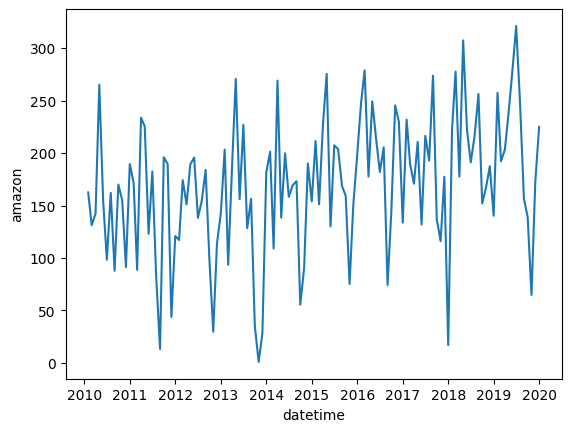

In [20]:
import seaborn as sns 

sns.lineplot(data=df_amazon, x="datetime",y="amazon")


<Axes: xlabel='datetime', ylabel='ebay'>

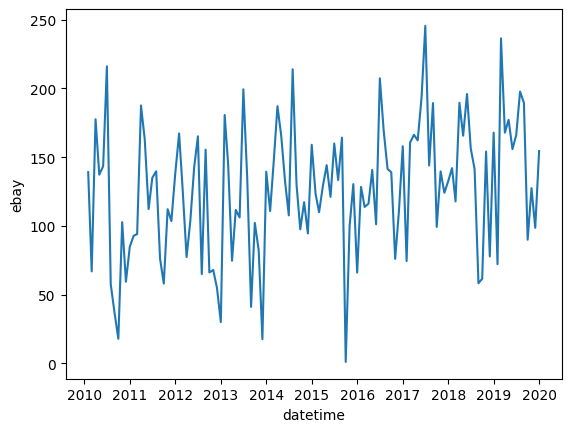

In [21]:

sns.lineplot(data=df_ebay, x="datetime",y="ebay")

<Axes: xlabel='datetime', ylabel='aliexpress'>

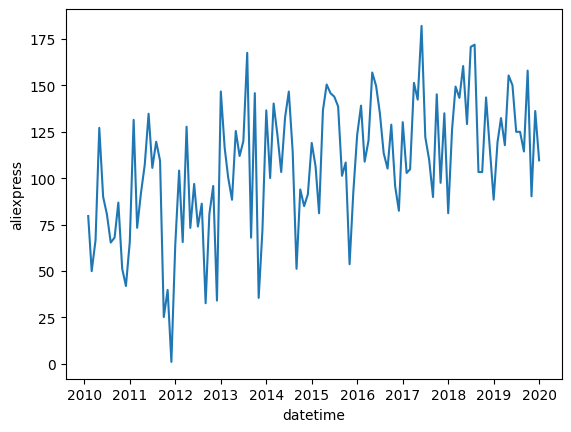

In [23]:
sns.lineplot(data=df_aliexpress, x="datetime",y="aliexpress")

<Axes: xlabel='datetime', ylabel='trendyol'>

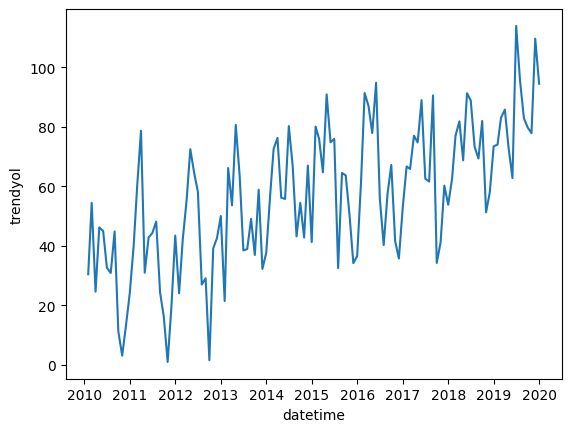

In [25]:
sns.lineplot(data=df_tredyol, x="datetime",y="trendyol")

### Vergleich der Entwicklung

In [28]:
# Unpivot von Wide zu Long
df_long = df.unpivot(
    index="datetime",       
    on=["amazon", "ebay", "aliexpress", "trendyol"], 
    variable_name="platform",   
    value_name="sales"         
)

df_long.head()

datetime,platform,sales
date,str,f64
2010-01-31,"""amazon""",162.50523
2010-02-28,"""amazon""",131.234988
2010-03-31,"""amazon""",142.409296
2010-04-30,"""amazon""",265.024017
2010-05-31,"""amazon""",154.458817


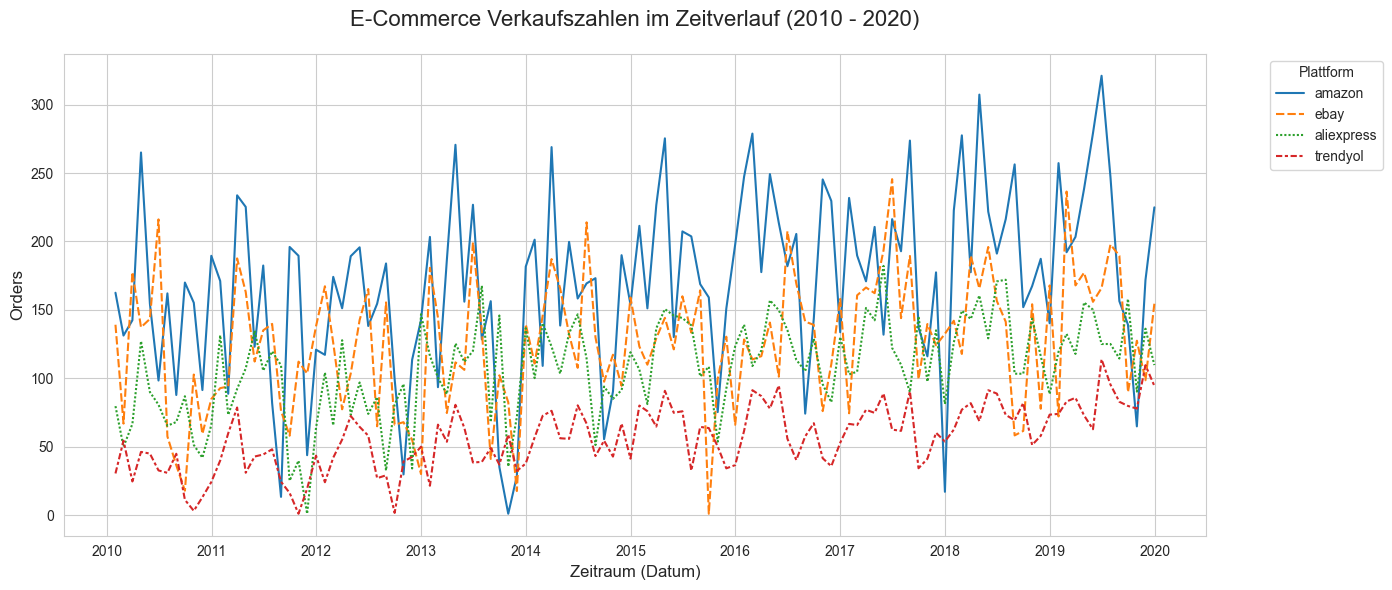

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

sns.set_style("whitegrid")

ax = sns.lineplot(
    data=df_long, 
    x="datetime", 
    y="sales", 
    hue="platform", 
    style="platform",
    linewidth=1.5 
)

plt.title("E-Commerce Verkaufszahlen im Zeitverlauf (2010 - 2020)", fontsize=16, pad=20)
plt.xlabel("Zeitraum (Datum)", fontsize=12)
plt.ylabel("Orders", fontsize=12)

plt.legend(title="Plattform", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()

plt.show()

## Datensatz wegschreiben

In [33]:
output_path = Path('..') / '02_data' / 'processed' / 'ecommerce_aliexpress.parquet'
output_path.parent.mkdir(parents=True, exist_ok=True)
df_aliexpress.write_parquet(output_path)

In [34]:
output_path = Path('..') / '02_data' / 'processed' / 'ecommerce_tredyol.parquet'
output_path.parent.mkdir(parents=True, exist_ok=True)
df_tredyol.write_parquet(output_path)

In [35]:
output_path = Path('..') / '02_data' / 'processed' / 'ecommerce_ebay.parquet'
output_path.parent.mkdir(parents=True, exist_ok=True)
df_ebay.write_parquet(output_path)

In [37]:
output_path = Path('..') / '02_data' / 'processed' / 'ecommerce_amazon.parquet'
output_path.parent.mkdir(parents=True, exist_ok=True)
df_amazon.write_parquet(output_path)

In [38]:
output_path = Path('..') / '02_data' / 'processed' / 'ecommerce_long_format.parquet'
output_path.parent.mkdir(parents=True, exist_ok=True)
df_long.write_parquet(output_path)